## European Energy Transition Overview

### Decarbonization Trends in Electricity Generation (1990–2025)

Over the past decades, Europe has undergone a significant transformation in its electricity generation mix, shifting away from fossil fuels towards **renewable energy sources**.

This analysis examines the evolution of the European power system by tracking the share of **renewable and fossil fuel generation** over time.

The objective of this analysis is to:
- Identify long-term decarbonization trends
- Assess the pace of renewable energy adoption
- Observe the decline of fossil fuel dependency

This high-level view provides the foundation for understanding how Europe's energy transition has evolved and sets the stage for deeper country-level analysis, including a focused case study on Portugal.

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

### Section 1: Data Loading and Preprocessing

In [ ]:
#File path
url = "https://raw.githubusercontent.com/davherdel/Energy-Transition-Decarbonization-Trends-and-Grid-Reliability/refs/heads/main/europe_yearly_full_release_long_format.csv"

#Load dataset
df = pd.read_csv(url)

#Preview
df.head()

,Area,ISO 3 code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity demand,Demand,Demand,TWh,48.81,NaN,NaN
1,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity demand,Demand per capita,Demand per capita,MWh,6.36,NaN,NaN
2,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Clean,%,66.25,NaN,NaN
3,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Coal,%,12.56,NaN,NaN
4,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Fossil,%,33.75,NaN,NaN


In [3]:
df['Category'].unique()

array(['Electricity demand', 'Electricity generation',
       'Electricity imports', 'Power sector emissions'], dtype=object)

In [4]:
df.columns = df.columns.str.lower()

In [5]:
df['category'].unique()

array(['Electricity demand', 'Electricity generation',
       'Electricity imports', 'Power sector emissions'], dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69348 entries, 0 to 69347
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   area                 69348 non-null  object 
 1   iso 3 code           67418 non-null  object 
 2   year                 69348 non-null  int64  
 3   area type            69348 non-null  object 
 4   continent            67418 non-null  object 
 5   ember region         67418 non-null  object 
 6   eu                   67418 non-null  float64
 7   oecd                 67418 non-null  float64
 8   g20                  67418 non-null  float64
 9   g7                   67418 non-null  float64
 10  asean                67418 non-null  float64
 11  category             69348 non-null  object 
 12  subcategory          69348 non-null  object 
 13  variable             69348 non-null  object 
 14  unit                 69348 non-null  object 
 15  value                69348 non-null 

In [7]:
df.columns

Index(['area', 'iso 3 code', 'year', 'area type', 'continent', 'ember region',
       'eu', 'oecd', 'g20', 'g7', 'asean', 'category', 'subcategory',
       'variable', 'unit', 'value', 'yoy absolute change', 'yoy % change'],
      dtype='object')

In [ ]:
# EU	OECD	G20	G7	ASEAN	
# Will take advantage of these columns for Data Vis

In [139]:
df['year'].unique(), df['variable'].unique(), df['ember region'].unique(), df['area'].unique()

(array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
        2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
        2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
        2023, 2024, 2025]),
 array(['Demand', 'Demand per capita', 'Clean', 'Coal', 'Fossil',
        'Hydro, bioenergy and other renewables', 'Renewables', 'Wind',
        'Wind and solar', 'Bioenergy', 'Gas', 'Hard coal', 'Hydro',
        'Lignite', 'Nuclear', 'Onshore wind', 'Other fossil',
        'Other renewables', 'Solar', 'Total generation', 'Net imports',
        'CO2 intensity', 'Offshore wind'], dtype=object),
 array(['Europe', nan], dtype=object),
 array(['Austria', 'Belgium', 'Bosnia Herzegovina', 'Bulgaria', 'Croatia',
        'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'EU', 'Finland',
        'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy',
        'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
        'Montenegro', 'Netherlands', 

In [23]:
# Filter for generation data only
df_gen = df[df["category"] == "Electricity generation"]
df_gen.head()

,area,iso 3 code,year,area type,continent,ember region,eu,oecd,g20,g7,asean,category,subcategory,variable,unit,value,yoy absolute change,yoy % change
2,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Clean,%,66.25,NaN,NaN
3,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Coal,%,12.56,NaN,NaN
4,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Fossil,%,33.75,NaN,NaN
5,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,"Hydro, bioenergy and other renewables",%,66.25,NaN,NaN
6,Austria,AUT,1990,Country or economy,Europe,Europe,1.0,1.0,0.0,0.0,0.0,Electricity generation,Aggregate fuel,Renewables,%,66.25,NaN,NaN


In [24]:
# FIlteting for Europe only
df_europa = df[df['ember region'] == 'Europe']

In [25]:
# Filtering for generation data in Europe
df_europa_gen = df_europa[df_europa["category"] == "Electricity generation"]

In [ ]:
# Filtering for 25 years worth of data
df_europa_gen = df_europa_gen[(df_europa_gen["year"] >= 2000) & (df_europa_gen["year"] <= 2025)]

In [ ]:
# Duplicate data will interfere with the results of the analysis, so we need to remove it
df_europa_gen[df_europa_gen["year"] == 2025].groupby("variable")["value"].sum().sort_values(ascending=False)

variable
Clean                                    4926.39
Renewables                               3737.05
Total generation                         3734.50
Fossil                                   2408.11
Wind and solar                           2049.11
Hydro, bioenergy and other renewables    1687.98
Hydro                                    1239.13
Gas                                      1216.06
Nuclear                                  1189.37
Wind                                     1163.81
Onshore wind                              978.24
Coal                                      900.01
Solar                                     885.32
Lignite                                   634.95
Bioenergy                                 422.49
Other fossil                              292.06
Hard coal                                 265.06
Offshore wind                             185.55
Other renewables                           26.31
Name: value, dtype: float64

In [33]:
# Check distribution across all years
df_europa_gen.groupby("variable")["value"].sum().sort_values(ascending=False)

variable
Fossil                                   133189.49
Total generation                         132028.81
Clean                                    127239.33
Renewables                                71186.20
Coal                                      67711.47
Nuclear                                   56053.11
Hydro, bioenergy and other renewables     53033.33
Hydro                                     44890.45
Gas                                       42179.05
Lignite                                   34433.74
Hard coal                                 33277.76
Other fossil                              23299.12
Wind and solar                            18152.71
Wind                                      13180.68
Onshore wind                              11586.59
Bioenergy                                  7655.08
Solar                                      4972.01
Offshore wind                              1594.03
Other renewables                            488.01
Name: value, dtype: fl

### Data Validation
To understand the dataset structure, a quick snapshot of the most recent year was analyzed, followed by a full validation across all available years.
This ensures that variable selection is consistent and not biased by a single year.

### Data Structure Observation
The dataset contains hierarchical energy categories, some variables represent aggregated values of others.

Examples:
- **"Wind"** includes both *"Onshore wind"* and *"Offshore wind"*
- **"Renewables"** includes *wind, solar, hydro, bioenergy*, and other *renewable sources*
- **"Wind and solar"** is a partial aggregate of two sources

This structure can lead to double counting if multiple levels are used **simultaneously**.

### Approach
To **ensure consistency and avoid duplication**, the analysis will focus only on **base-level** energy sources:

- Coal
- Gas
- Oil
- Wind
- Solar
- Hydro
- Nuclear
- Bioenergy
- Other renewables

All aggregated variables will be excluded.

In [43]:
valid_sources = [
    "Coal",
    "Gas",
    "Oil",
    "Wind",
    "Solar",
    "Hydro",
    "Nuclear",
    "Bioenergy",
    "Other renewables"
]

df_europa_gen = df_europa_gen[df_europa_gen["variable"].isin(valid_sources)]
df_europa_gen["variable"].unique()

array(['Coal', 'Wind', 'Bioenergy', 'Gas', 'Hydro', 'Nuclear',
       'Other renewables', 'Solar'], dtype=object)

In [45]:
df_europe_total = df_europa_gen.groupby(["year", "variable"])["value"].sum().reset_index()
df_europe_total.head()

,year,variable,value
0,1990,Bioenergy,35.40
1,1990,Coal,2323.82
2,1990,Gas,572.21
3,1990,Hydro,1029.57
4,1990,Nuclear,1452.06


In [ ]:
# Creating total per year
df_total = df_europe_total.groupby("year")["value"].sum().reset_index()
df_total.rename(columns={"value": "total_generation"}, inplace=True)
df_total.head()

,year,total_generation
0,1990,5421.90
1,1991,5429.07
2,1992,5394.51
3,1993,5430.05
4,1994,5456.13


In [50]:
renewables = ["Wind", "Solar", "Hydro", "Bioenergy", "Other renewables"]
fossil = ["Coal", "Gas", "Oil"]

In [56]:
# Renewables and fossil fuel generation per year

df_renew = df_europe_total[df_europe_total["variable"].isin(renewables)] \
    .groupby("year")["value"].sum().reset_index()
df_renew.rename(columns={"value": "renewable_generation"}, inplace=True)

In [58]:
df_renew.head()

,year,renewable_generation
0,1990,1073.81
1,1991,1112.31
2,1992,1125.15
3,1993,1177.03
4,1994,1203.77


In [ ]:
# Fossil
df_fossil = df_europe_total[df_europe_total["variable"].isin(fossil)] \
    .groupby("year")["value"].sum().reset_index()
df_fossil.rename(columns={"value": "fossil_generation"}, inplace=True)

In [59]:
df_fossil.head()

,year,fossil_generation
0,1990,2896.03
1,1991,2842.23
2,1992,2777.32
3,1993,2701.91
4,1994,2712.78


In [61]:
df_final = df_total.merge(df_renew, on="year") \
                   .merge(df_fossil, on="year")
df_final.head()

,year,total_generation,renewable_generation,fossil_generation
0,1990,5421.90,1073.81,2896.03
1,1991,5429.07,1112.31,2842.23
2,1992,5394.51,1125.15,2777.32
3,1993,5430.05,1177.03,2701.91
4,1994,5456.13,1203.77,2712.78


In [63]:
df_final["renewable_share"] = df_final["renewable_generation"] / df_final["total_generation"]
df_final["fossil_share"] = df_final["fossil_generation"] / df_final["total_generation"]
df_final.head()

,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share
0,1990,5421.90,1073.81,2896.03,0.198050,0.534136
1,1991,5429.07,1112.31,2842.23,0.204880,0.523521
2,1992,5394.51,1125.15,2777.32,0.208573,0.514842
3,1993,5430.05,1177.03,2701.91,0.216762,0.497585
4,1994,5456.13,1203.77,2712.78,0.220627,0.497199


In [69]:
# YoY growth (Year over Year)
df_final["renewable_yoy_growth"] = df_final["renewable_generation"].pct_change()
df_final.head()

,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share,renewable_yoy_growth
0,1990,5421.90,1073.81,2896.03,0.198050,0.534136,NaN
1,1991,5429.07,1112.31,2842.23,0.204880,0.523521,0.035854
2,1992,5394.51,1125.15,2777.32,0.208573,0.514842,0.011544
3,1993,5430.05,1177.03,2701.91,0.216762,0.497585,0.046109
4,1994,5456.13,1203.77,2712.78,0.220627,0.497199,0.022718


In [66]:
df_final.head()
df_final.tail()

,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share,renewable_yoy_growth
31,2021,7309.51,3126.87,2754.56,0.427781,0.376846,0.014967
32,2022,7132.08,3138.33,2700.51,0.440030,0.378643,0.003665
33,2023,6901.94,3483.15,2240.88,0.504662,0.324674,0.109874
34,2024,7005.05,3703.55,2100.79,0.528697,0.299897,0.063276
35,2025,7042.50,3737.06,2116.07,0.530644,0.300471,0.009048


In [ ]:
# Saving the final dataframe to a CSV file
# Dataset A: Europe (Macro)
df_final.to_csv("europe_energy_transition_clean.csv", index=False)

In [ ]:
# Creating Dataset B: Country-level data for Europe
df_country_total = df_europa_gen.groupby(["area", "year", "variable"])["value"].sum().reset_index()
df_country_total.head()

,area,year,variable,value
0,Austria,1990,Bioenergy,3.42
1,Austria,1990,Coal,18.75
2,Austria,1990,Gas,23.39
3,Austria,1990,Hydro,95.46
4,Austria,1990,Nuclear,0.00


In [75]:
df_country_total_gen = df_country_total.groupby(["area", "year"])["value"].sum().reset_index()
df_country_total_gen.rename(columns={"value": "total_generation"}, inplace=True)

In [78]:
# Renewables and fossil fuel generation per year
# Renewables
df_country_renew = df_country_total[df_country_total["variable"].isin(renewables)] \
    .groupby(["area", "year"])["value"].sum().reset_index()

df_country_renew.rename(columns={"value": "renewable_generation"}, inplace=True)
df_country_renew.head()

,area,year,renewable_generation
0,Austria,1990,98.88
1,Austria,1991,97.74
2,Austria,1992,108.64
3,Austria,1993,112.21
4,Austria,1994,107.93


In [79]:
# Fossil
df_country_fossil = df_country_total[df_country_total["variable"].isin(fossil)] \
    .groupby(["area", "year"])["value"].sum().reset_index()

df_country_fossil.rename(columns={"value": "fossil_generation"}, inplace=True)
df_country_fossil.head()

,area,year,fossil_generation
0,Austria,1990,42.14
1,Austria,1991,42.84
2,Austria,1992,32.30
3,Austria,1993,28.81
4,Austria,1994,34.34


In [81]:
df_country_final = df_country_total_gen.merge(df_country_renew, on=["area", "year"]) \
                                       .merge(df_country_fossil, on=["area", "year"])
df_country_final.head()

,area,year,total_generation,renewable_generation,fossil_generation
0,Austria,1990,141.02,98.88,42.14
1,Austria,1991,140.58,97.74,42.84
2,Austria,1992,140.94,108.64,32.30
3,Austria,1993,141.02,112.21,28.81
4,Austria,1994,142.27,107.93,34.34


In [83]:
# Shares
df_country_final["renewable_share"] = df_country_final["renewable_generation"] / df_country_final["total_generation"]
df_country_final["fossil_share"] = df_country_final["fossil_generation"] / df_country_final["total_generation"]
df_country_final.head()

,area,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share
0,Austria,1990,141.02,98.88,42.14,0.701177,0.298823
1,Austria,1991,140.58,97.74,42.84,0.695262,0.304738
2,Austria,1992,140.94,108.64,32.30,0.770824,0.229176
3,Austria,1993,141.02,112.21,28.81,0.795703,0.204297
4,Austria,1994,142.27,107.93,34.34,0.758628,0.241372


In [85]:
# Calculating YoY growth for renewables at country level
df_country_final["renewable_yoy_growth"] = (
    df_country_final
    .sort_values(["area", "year"])
    .groupby("area")["renewable_generation"]
    .pct_change()
)

df_country_final.head(10)

,area,year,total_generation,renewable_generation,fossil_generation,renewable_share,fossil_share,renewable_yoy_growth
0,Austria,1990,141.02,98.88,42.14,0.701177,0.298823,NaN
1,Austria,1991,140.58,97.74,42.84,0.695262,0.304738,-0.011529
2,Austria,1992,140.94,108.64,32.30,0.770824,0.229176,0.111520
3,Austria,1993,141.02,112.21,28.81,0.795703,0.204297,0.032861
4,Austria,1994,142.27,107.93,34.34,0.758628,0.241372,-0.038143
5,Austria,1995,146.86,109.59,37.27,0.746221,0.253779,0.015380
6,Austria,1996,144.90,102.75,42.15,0.709110,0.290890,-0.062414
7,Austria,1997,145.89,105.86,40.03,0.725615,0.274385,0.030268
8,Austria,1998,145.24,108.95,36.29,0.750138,0.249862,0.029189
9,Austria,1999,149.93,113.26,36.67,0.755419,0.244581,0.039559


In [87]:
# Saving the final dataframe to a CSV file
# Dataset B: Country-level (Detail)

df_country_final.to_csv("country_energy_transition_clean.csv", index=False)

### Section 2 - Chart creation prior to Power Bi dashboard
### Something about renewable and fossil, basically describe the charts

### Country-Level Electricity Generation Ranking

Countries are selected based on a combination of **system size, geographic relevance**, and **energy transition characteristics**.

**Portugal is the focus of the analysis**, supported by a diverse group of European countries that provide meaningful benchmarks:

- Spain *(regional comparison)*
- France and Germany *(large-scale systems)*
- United Kingdom and Italy *(major European energy markets)*
- Denmark *(renewable energy leader)*
- Netherlands *(recent transition dynamics)*
- Poland *(fossil-heavy system, useful contrast)*
- Belgium *(included for regional and institutional relevance within the EU)*

While only a subset of countries was selected for the final analysis, the full list is shown for context.


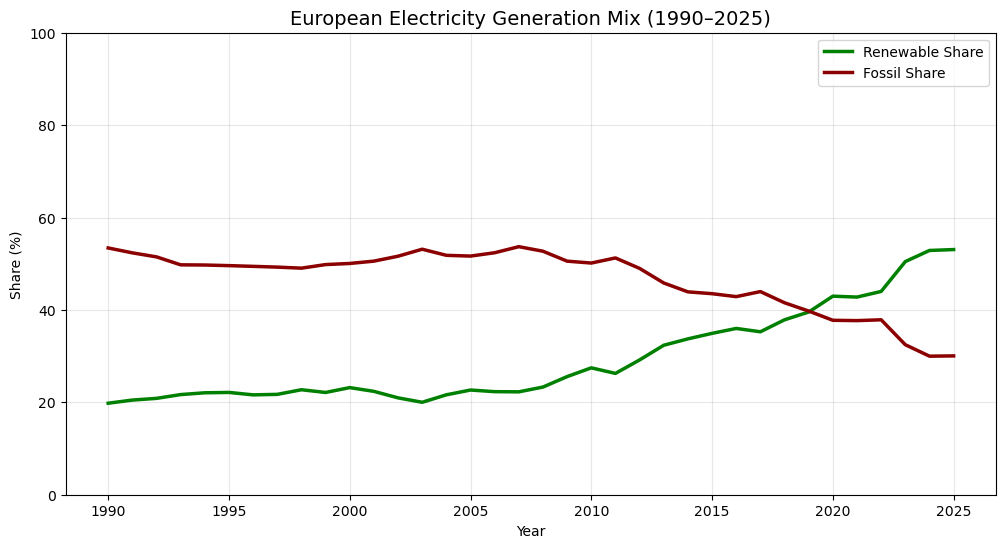

In [96]:
plt.figure(figsize=(12,6))

# Colors with intention and percentage conversion, no decimal places
plt.plot(df_final["year"], df_final["renewable_share"] * 100, 
         label="Renewable Share", color="green", linewidth=2.5)

plt.plot(df_final["year"], df_final["fossil_share"] * 100, 
         label="Fossil Share", color="darkred", linewidth=2.5)

plt.title("European Electricity Generation Mix (1990–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Share (%)")

plt.ylim(0, 100)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [121]:
# Create country-level average generation ranking
country_generation_ranking = (
    df_country_final
    .groupby("area")["total_generation"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Renaming columns for clarity
country_generation_ranking.columns = ["Country", "Average Generation (TWh)"]

# Rounding values for better readability
country_generation_ranking["Average Generation (TWh)"] = \
    country_generation_ranking["Average Generation (TWh)"].round(2)

country_generation_ranking

,Country,Average Generation (TWh)
0,Germany,653.30
1,France,619.90
2,United Kingdom,431.29
3,Spain,321.68
4,Italy,292.23
5,Türkiye,286.87
6,Ukraine,278.90
7,Sweden,248.78
8,Poland,247.01
9,Norway,231.29


In [102]:
countries = [
    "Portugal",   
    "Spain",        
    "France",       
    "Germany",       
    "Denmark",   
    "Netherlands",
    "United Kingdom",
    "Italy",
    "Poland",
    "Belgium"
]

In [103]:
# Filtering dataset
df_selected = df_country_final[df_country_final["area"].isin(countries)]

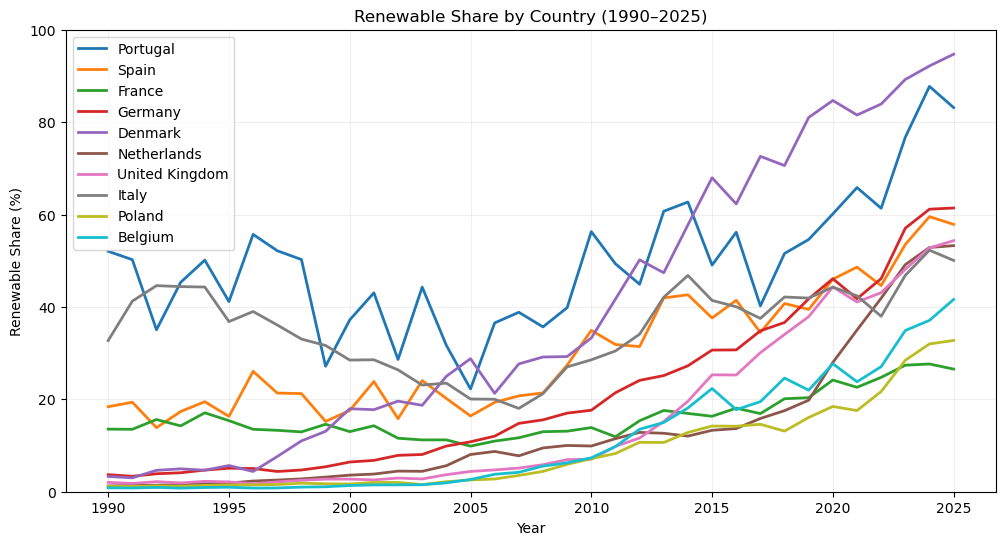

In [108]:
# Country Renewable Share Trends
plt.figure(figsize=(12,6))

for country in countries:
    data = df_selected[df_selected["area"] == country]
    
    plt.plot(
        data["year"], 
        data["renewable_share"] * 100,
        label=country,
        linewidth=2
    )

plt.title("Renewable Share by Country (1990–2025)", fontsize=12)
plt.xlabel("Year")
plt.ylabel("Renewable Share (%)")

plt.ylim(0, 100)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

The selected countries reflect a **diverse set of energy systems** across Europe, ranging from renewable leaders to fossil-dependent economies. As shown in the chart, **Denmark leads in renewable energy share**, while Poland remains more reliant on fossil fuels. **Portugal performs strongly**, positioning itself above several large European economies.

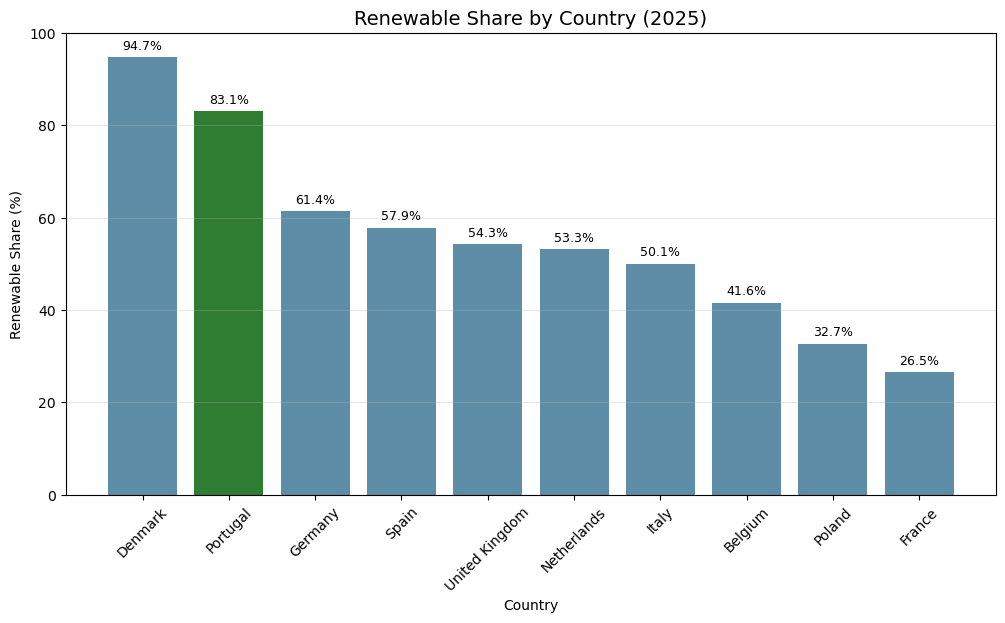

In [ ]:
# Latest year
latest_year = df_selected["year"].max()

# Filter latest data
df_latest = df_selected[df_selected["year"] == latest_year]

# Sorting by renewable share
df_latest = df_latest.sort_values(by="renewable_share", ascending=False)

# Colors (highlight Portugal)
colors = ["#2E7D32" if c == "Portugal" else "#B0BEC5" for c in df_latest["area"]]

plt.figure(figsize=(12,6))

bars = plt.bar(
    df_latest["area"],
    df_latest["renewable_share"] * 100,
    color=colors
)

# Adding value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title(f"Renewable Share by Country ({latest_year})", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Renewable Share (%)")

plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.grid(axis="y", alpha=0.3)

plt.show()

The selected countries highlight **different pathways in reducing fossil fuel dependency**.

As shown in the chart, **France maintains a consistently low fossil fuel share**, largely due to its strong reliance on nuclear energy rather than renewable sources. In contrast, **Denmark demonstrates a significant decline in fossil dependency**, driven by rapid renewable energy adoption.

**Portugal shows a steady reduction in fossil fuel reliance**, indicating a balanced and consistent energy transition. Meanwhile, **Poland remains one of the most fossil-dependent systems**, with only gradual improvements over time.

Overall, the chart reveals that while fossil fuel dependency is declining across Europe, **the pace and drivers of this transition vary significantly by country**.

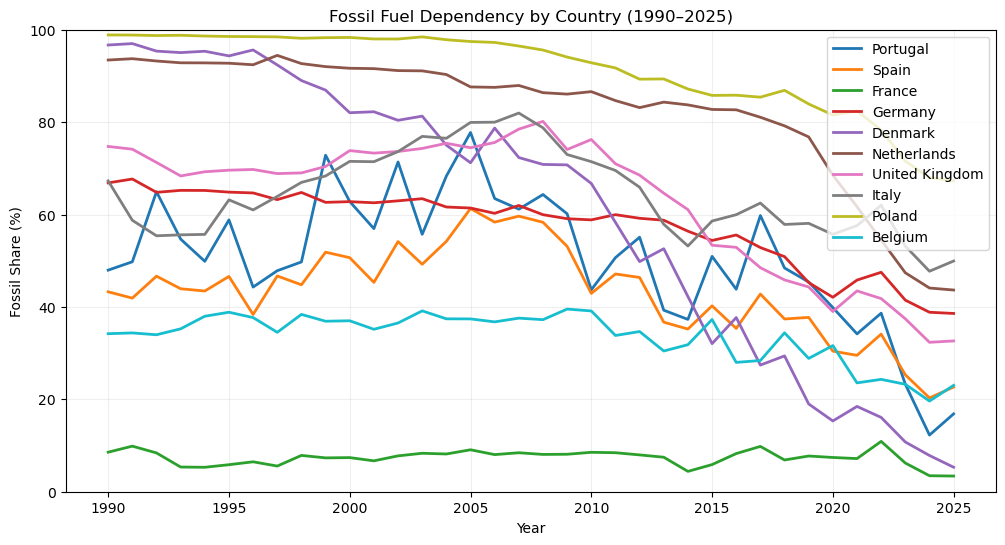

In [130]:
# Country Fossil Share Trends
plt.figure(figsize=(12,6))

for country in countries:
    data = df_selected[df_selected["area"] == country]
    
    plt.plot(
        data["year"], 
        data["fossil_share"] * 100,
        label=country,
        linewidth=2
    )

plt.title("Fossil Fuel Dependency by Country (1990–2025)", fontsize=12)
plt.xlabel("Year")
plt.ylabel("Fossil Share (%)")

plt.ylim(0, 100)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

**Electricity Generation Mix by Country**

This chart shows the composition of electricity generation across selected European countries.
It provides context for understanding differences in renewable adoption and fossil fuel dependency by revealing the underlying energy sources in each system.

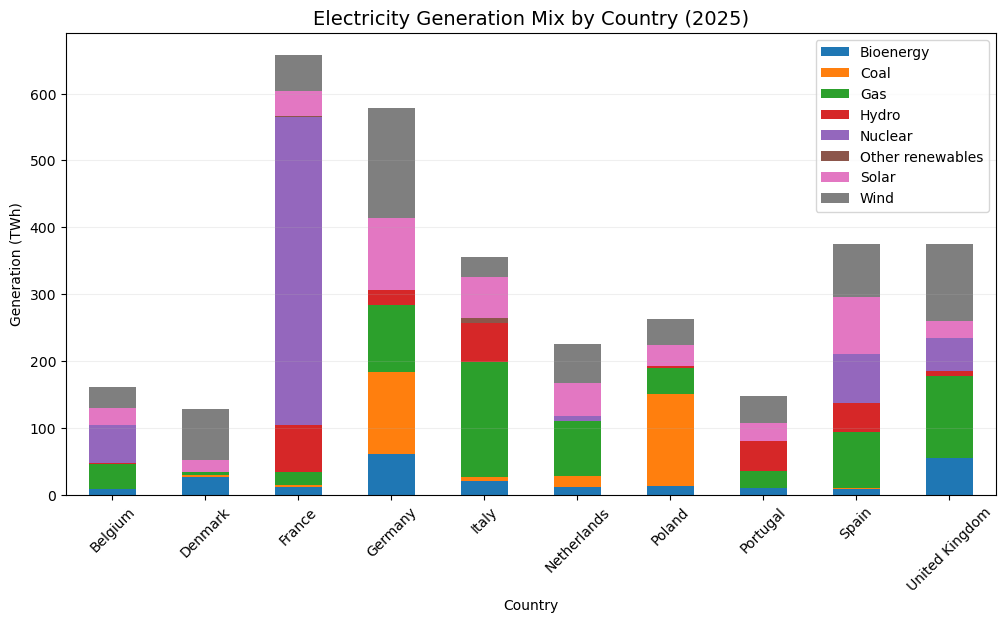

In [131]:
# Country Generation Mix
# Latest year
latest_year = df_country_total["year"].max()

# Filter latest data
df_latest_mix = df_country_total[df_country_total["year"] == latest_year]

# Filter selected countries
df_latest_mix = df_latest_mix[df_latest_mix["area"].isin(countries)]

# Pivot
df_pivot_mix = df_latest_mix.pivot(
    index="area",
    columns="variable",
    values="value"
)

# Plot
df_pivot_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title(f"Electricity Generation Mix by Country ({latest_year})", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Generation (TWh)")

plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1,1))
plt.grid(axis="y", alpha=0.2)

plt.show()

### Case Study: France — A Low-Carbon System Without Heavy Renewable Reliance

<Figure size 1200x600 with 0 Axes>

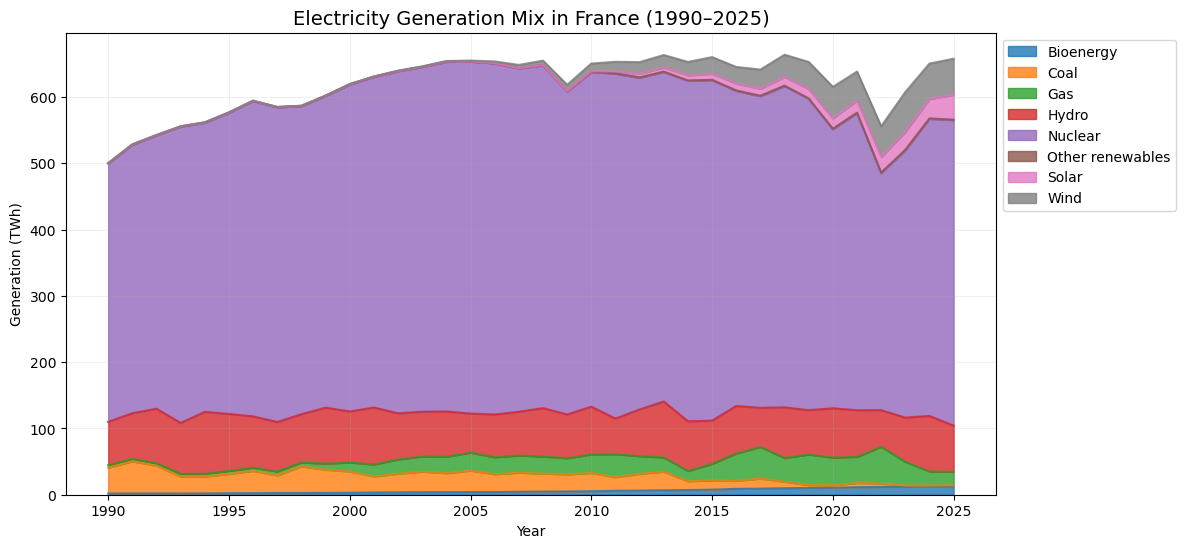

In [136]:
country = "France"
df_country = df_country_total[df_country_total["area"] == country]


df_pivot = df_country.pivot(
    index="year",
    columns="variable",
    values="value"
)


plt.figure(figsize=(12,6))

df_pivot.plot.area(
    stacked=True,
    figsize=(12,6),
    alpha=0.8
)

plt.title(f"Electricity Generation Mix in {country} (1990–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Generation (TWh)")

plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.grid(alpha=0.2)

plt.show()

France stands out among European countries for maintaining a **consistently low level of fossil fuel dependency** over time.

As shown in the energy mix, this is primarily driven by its **strong reliance on nuclear power**, which dominates electricity generation. Unlike countries such as Denmark or Portugal, France's transition has not been led by *rapid renewable expansion*, but rather by an already established **low-carbon foundation**.

This highlights an alternative pathway in the energy transition:  
while many countries reduce fossil dependency through renewables, France achieves similar outcomes through nuclear energy.

As a result, France presents a *unique case* where low emissions and low fossil dependency coexist without a high share of renewables. 

### Case Study: Portugal — A Diversified and Renewable-Driven Transition

<Figure size 1200x600 with 0 Axes>

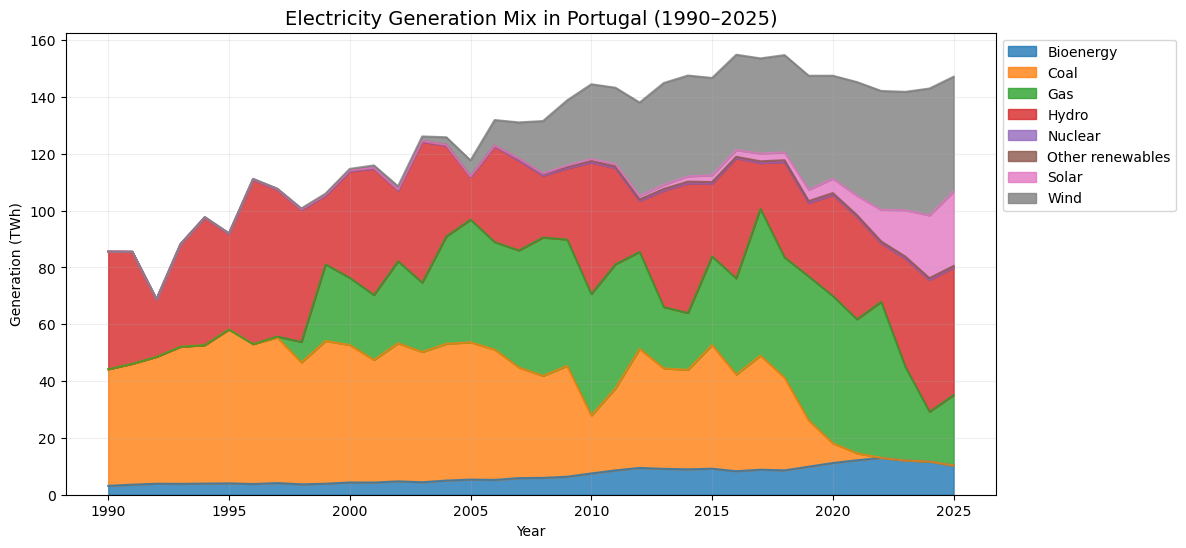

In [135]:
country_pt = "Portugal"

df_country_pt = df_country_total[df_country_total["area"] == country_pt]

df_pivot_pt = df_country_pt.pivot(
    index="year",
    columns="variable",
    values="value"
)

plt.figure(figsize=(12,6))

df_pivot_pt.plot.area(
    stacked=True,
    figsize=(12,6),
    alpha=0.8
)

plt.title(f"Electricity Generation Mix in {country_pt} (1990–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Generation (TWh)")

plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.grid(alpha=0.2)

plt.show()

Portugal presents a **well-balanced and progressively evolving** electricity system, driven primarily by **renewable energy expansion**.

The energy mix reveals a strong and sustained growth in **wind and hydro generation**, complemented by solar in more recent years. Unlike fossil-dependent systems, Portugal shows a clear reduction in fossil fuel contribution over time.

A key strength of Portugal’s transition is its **diversification across multiple renewable sources**, reducing reliance on any single technology and enhancing system resilience.

This results in a transition where **increasing renewable adoption** directly translates into **declining fossil dependency** — positioning Portugal as a strong example of a consistent and effective decarbonization pathway.

### Section 3 - Generation VS Demand

In [144]:
# Filtering demand and genertion

df_demand = df[df["category"] == "Electricity demand"]
df_generation = df[df["category"] == "Electricity generation"]

In [149]:
# Grouping by area and year to get total demand and generation

df_demand_grouped = df_demand.groupby(["area", "year"])["value"].sum().reset_index()
df_generation_grouped = df_generation.groupby(["area", "year"])["value"].sum().reset_index()

df_demand_grouped.rename(columns={"value": "demand"}, inplace=True)
df_generation_grouped.rename(columns={"value": "generation"}, inplace=True)

# Merge
df_balance = df_generation_grouped.merge(
    df_demand_grouped,
    on=["area", "year"]
)

# Balance
df_balance["balance"] = df_balance["generation"] - df_balance["demand"]

In [150]:
# Latest year
latest_year = df_balance["year"].max()

df_balance_latest = df_balance[df_balance["year"] == latest_year]

# Filter selected countries
df_balance_latest = df_balance_latest[df_balance_latest["area"].isin(countries)]

# Sort by balance
df_balance_latest = df_balance_latest.sort_values(by="balance", ascending=False)

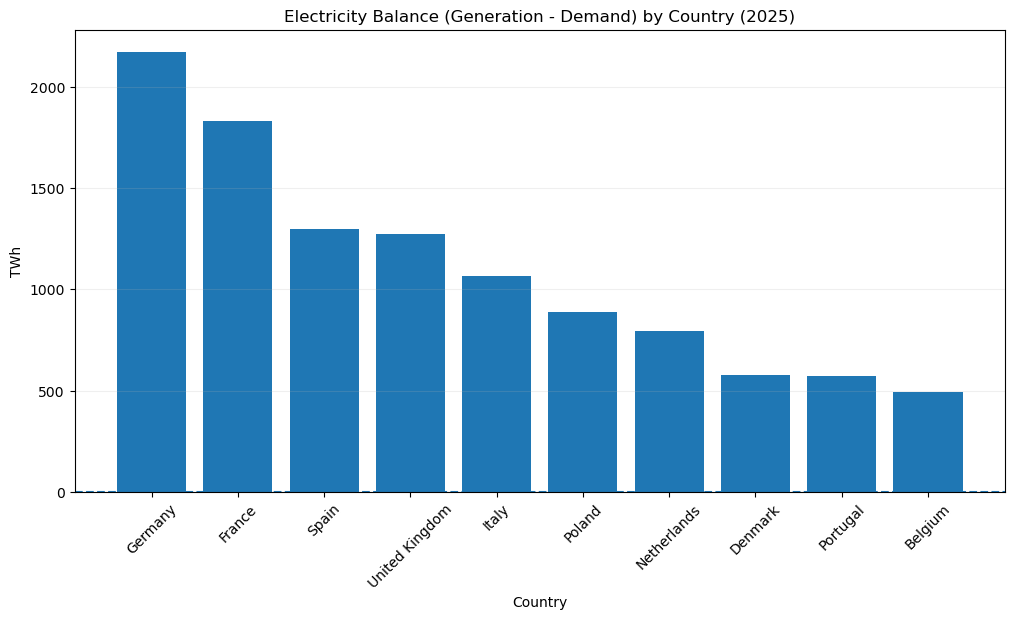

In [151]:
plt.figure(figsize=(12,6))

plt.bar(
    df_balance_latest["area"],
    df_balance_latest["balance"]
)

plt.axhline(0, linestyle="--")  # línea de equilibrio

plt.title(f"Electricity Balance (Generation - Demand) by Country ({latest_year})")
plt.xlabel("Country")
plt.ylabel("TWh")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)

plt.show()

## Need to analyze this after some cupS of coffee

### Data Sources:
[Ember Energy](https://ember-energy.org/data/yearly-electricity-data/)
"Summary: This dataset contains yearly electricity generation, capacity, emissions, import and demand data for over 200 geographies. Data is collected from multi-country datasets (EIA, Eurostat, BP, UN) as well as national sources (e.g China data from the National Bureau of Statistics).

Our yearly electricity data is kept up to date throughout the year and is regularly amended with the latest available data. The data is updated twice a month with an update in the first week of the month followed by a second update in the third week of the month."